# 1. Setup
# 2. Load Data
# 3. Data Overview
# 4. Data Quality Check
# 5. Exploratory Analysis
# 6. Key Insights

In [538]:
import pandas as pd

csv_path = "/Users/Alex/Documents/FYP v.2/Traffic Intelligence/dft_rawcount_local_authority_id_141.csv"

df = pd.read_csv(csv_path)

print("Dataset Loaded Successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset Loaded Successfully
Rows: 72,948
Columns: 32


/var/folders/2h/vlvc2dcn6m9fx273497hnf300000gp/T/ipykernel_78648/653948930.py:5: DtypeWarning: Columns (0: start_junction_road_name, 1: end_junction_road_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,count_point_id,direction_of_travel,year,count_date,hour,region_id,region_name,local_authority_id,local_authority_name,road_name,...,buses_and_coaches,lgvs,hgvs_2_rigid_axle,hgvs_3_rigid_axle,hgvs_4_or_more_rigid_axle,hgvs_3_or_4_articulated_axle,hgvs_5_articulated_axle,hgvs_6_articulated_axle,all_hgvs,all_motor_vehicles
0,6358,N,2000,2000-05-10,10,10,West Midlands,141,Birmingham,A34,...,72,123,20,3,1,2,3,3,32,734
1,6358,N,2000,2000-05-10,12,10,West Midlands,141,Birmingham,A34,...,52,103,11,3,3,0,1,2,20,684
2,6358,N,2000,2000-05-10,9,10,West Midlands,141,Birmingham,A34,...,64,112,14,3,2,0,1,4,24,774
3,6358,N,2000,2000-05-10,17,10,West Midlands,141,Birmingham,A34,...,60,91,6,0,0,1,0,0,7,1449
4,6358,N,2000,2000-05-10,11,10,West Midlands,141,Birmingham,A34,...,51,135,17,3,3,0,3,1,27,802


In [539]:
print("\nColumn Names:\n")

for col in df.columns:
    print(col)


Column Names:

count_point_id
direction_of_travel
year
count_date
hour
region_id
region_name
local_authority_id
local_authority_name
road_name
road_type
start_junction_road_name
end_junction_road_name
easting
northing
latitude
longitude
link_length_km
link_length_miles
pedal_cycles
two_wheeled_motor_vehicles
cars_and_taxis
buses_and_coaches
lgvs
hgvs_2_rigid_axle
hgvs_3_rigid_axle
hgvs_4_or_more_rigid_axle
hgvs_3_or_4_articulated_axle
hgvs_5_articulated_axle
hgvs_6_articulated_axle
all_hgvs
all_motor_vehicles


In [540]:
print("Years Covered:")
print(df["year"].min(), "to", df["year"].max())

print("\nUnique Count Points:")
print(df["count_point_id"].nunique())

print("\nUnique Roads:")
print(df["road_name"].nunique())

Years Covered:
2000 to 2025

Unique Count Points:
562

Unique Roads:
50


In [541]:
print(df["all_motor_vehicles"].describe())

count    72948.000000
mean       536.869866
std        783.305472
min          0.000000
25%         50.000000
50%        262.000000
75%        674.000000
max       7061.000000
Name: all_motor_vehicles, dtype: float64


In [542]:
top_roads = (
    df.groupby("road_name")["all_motor_vehicles"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_roads)

road_name
M6        4061.964583
A38(M)    3382.958333
A38M      3290.934524
A4400     1670.522388
A38       1527.024632
A45       1519.841009
A4540     1514.093225
A456      1272.498984
A34       1198.039644
A4041     1114.569444
Name: all_motor_vehicles, dtype: float64


In [543]:
hourly = (
    df.groupby("hour")["all_motor_vehicles"]
      .mean()
      .sort_values(ascending=False)
)

print(hourly)

hour
8     623.361902
16    617.336404
17    614.540385
15    567.889291
7     564.359763
18    527.998848
14    517.543346
9     510.839447
13    503.448923
12    485.165488
11    458.914295
10    451.040303
Name: all_motor_vehicles, dtype: float64


In [544]:
direction = (
    df.groupby("direction_of_travel")["all_motor_vehicles"]
      .mean()
      .sort_values(ascending=False)
)

print(direction)

direction_of_travel
W    560.129114
E    547.843378
N    527.370142
S    522.188367
Name: all_motor_vehicles, dtype: float64


In [545]:
road_type = (
    df.groupby("road_type")["all_motor_vehicles"]
      .mean()
      .sort_values(ascending=False)
)

print(road_type)

road_type
Major    1304.399648
Minor     177.391546
Name: all_motor_vehicles, dtype: float64


In [546]:
df.isnull().sum().sort_values(ascending=False)

link_length_miles               49680
end_junction_road_name          49680
start_junction_road_name        49680
link_length_km                  49680
lgvs                                0
pedal_cycles                        0
two_wheeled_motor_vehicles          0
cars_and_taxis                      0
buses_and_coaches                   0
count_point_id                      0
hgvs_3_rigid_axle                   0
hgvs_4_or_more_rigid_axle           0
hgvs_3_or_4_articulated_axle        0
hgvs_5_articulated_axle             0
hgvs_6_articulated_axle             0
all_hgvs                            0
hgvs_2_rigid_axle                   0
longitude                           0
direction_of_travel                 0
latitude                            0
northing                            0
easting                             0
road_type                           0
road_name                           0
local_authority_name                0
local_authority_id                  0
region_name 

In [547]:
print(df.duplicated().sum())

0


In [548]:
df[
    [
        "road_name",
        "start_junction_road_name",
        "end_junction_road_name",
        "link_length_km"
    ]
].sample(20)

,road_name,start_junction_road_name,end_junction_road_name,link_length_km
57560,U,NaN,NaN,NaN
48577,U,NaN,NaN,NaN
5316,A4540,A441,A38,0.2
28664,C,NaN,NaN,NaN
36612,U,NaN,NaN,NaN
36485,U,NaN,NaN,NaN
54955,U,NaN,NaN,NaN
49906,U,NaN,NaN,NaN
15070,A4040,A457,A41,2.1
10217,A34,B4025 roundabout,A4040,0.9


In [549]:
major_minor = (
    df.groupby("road_type")["all_motor_vehicles"]
      .agg(["count", "mean", "median", "max"])
)

major_minor

,count,mean,median,max
road_type,,,,
Major,23268,1304.399648,978.0,7061
Minor,49680,177.391546,99.0,1376


In [550]:
direction_stats = (
    df.groupby("direction_of_travel")["all_motor_vehicles"]
      .agg(["count", "mean", "median", "max"])
)

direction_stats

,count,mean,median,max
direction_of_travel,,,,
E,15132,547.843378,279.0,6597
N,21408,527.370142,247.0,7061
S,21336,522.188367,243.0,6683
W,15072,560.129114,283.0,6650


In [551]:
yearly_traffic = (
    df.groupby("year")["all_motor_vehicles"]
      .mean()
      .reset_index()
)

yearly_traffic.head()

,year,all_motor_vehicles
0,2000,896.356303
1,2001,938.040090
2,2002,740.359345
3,2003,698.915972
4,2004,622.052177


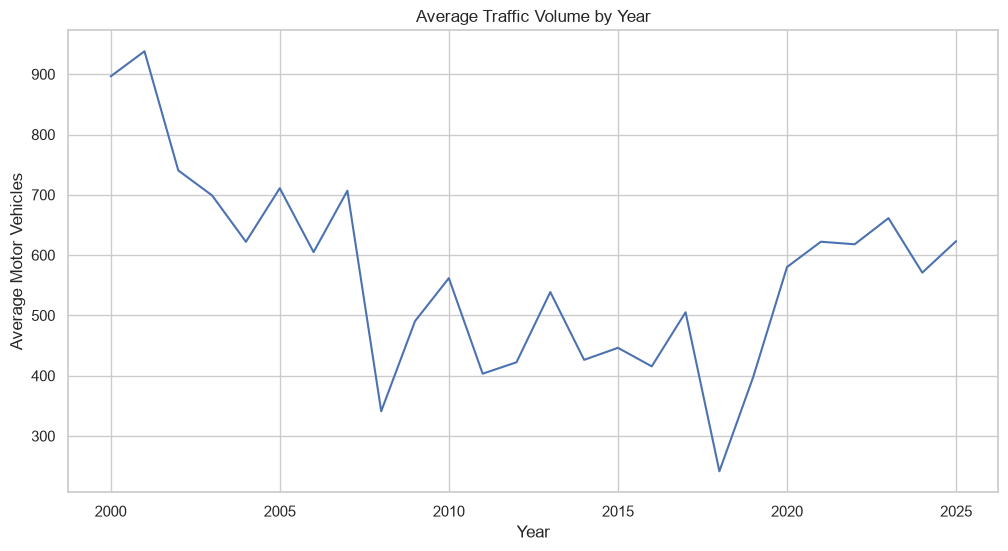

In [552]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    yearly_traffic["year"],
    yearly_traffic["all_motor_vehicles"]
)

plt.title("Average Traffic Volume by Year")
plt.xlabel("Year")
plt.ylabel("Average Motor Vehicles")

plt.show()

In [553]:
top_roads = (
    df.groupby("road_name")["all_motor_vehicles"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

top_roads

road_name
M6        4061.964583
A38(M)    3382.958333
A38M      3290.934524
A4400     1670.522388
A38       1527.024632
A45       1519.841009
A4540     1514.093225
A456      1272.498984
A34       1198.039644
A4041     1114.569444
A452      1094.922500
B4284      860.694444
A453       853.755051
A5127      803.130303
A41        733.420139
A457       702.557692
A441       701.380208
A4123      686.291667
A47        675.022523
A4040      671.139245
Name: all_motor_vehicles, dtype: float64

In [554]:
df["is_morning_peak"] = df["hour"].isin([7, 8, 9]).astype(int)

df["is_evening_peak"] = df["hour"].isin([16, 17, 18]).astype(int)

df["is_peak_hour"] = (
    df["is_morning_peak"] |
    df["is_evening_peak"]
).astype(int)

In [555]:
df[[
    "hour",
    "is_morning_peak",
    "is_evening_peak",
    "is_peak_hour"
]].head(10)

,hour,is_morning_peak,is_evening_peak,is_peak_hour
0,10,0,0,0
1,12,0,0,0
2,9,1,0,1
3,17,0,1,1
4,11,0,0,0
5,16,0,1,1
6,8,1,0,1
7,9,1,0,1
8,12,0,0,0
9,11,0,0,0


In [556]:
from sklearn.model_selection import train_test_split

features = [
    "year",
    "hour",
    "direction_of_travel",
    "road_type",
    "road_name",
    "count_point_id",
    "latitude",
    "longitude",
    "is_morning_peak",
    "is_evening_peak",
    "is_peak_hour"
]

X = df[features]
y = df["all_motor_vehicles"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(58358, 11) (14590, 11)


In [557]:
numeric_features = ["year", "hour", "latitude", "longitude", "count_point_id"]

categorical_features = ["road_name", "road_type", "direction_of_travel"]

In [558]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [559]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [560]:
df[[
    "hour",
    "is_morning_peak",
    "is_evening_peak",
    "is_peak_hour"
]].head(10)

,hour,is_morning_peak,is_evening_peak,is_peak_hour
0,10,0,0,0
1,12,0,0,0
2,9,1,0,1
3,17,0,1,1
4,11,0,0,0
5,16,0,1,1
6,8,1,0,1
7,9,1,0,1
8,12,0,0,0
9,11,0,0,0


In [561]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [562]:
df["road_direction"] = (
    df["road_name"].astype(str)
    + "_"
    + df["direction_of_travel"].astype(str)
)

In [563]:
from sklearn.model_selection import train_test_split

features = [
    "year",
    "hour",
    "direction_of_travel",
    "road_type",
    "road_name",
    "count_point_id",
    "latitude",
    "longitude",
    "is_morning_peak",
    "is_evening_peak",
    "is_peak_hour"
]

X = df[features]

y = df["all_motor_vehicles"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [564]:
print(X_train)

       year  hour direction_of_travel road_type road_name  count_point_id  \
32798  2004    13                   E     Minor     B4217          930056   
6133   2021     9                   W     Major       A38           26393   
18960  2000    15                   S     Major       A38           57233   
32757  2009    18                   W     Minor     B4114          930055   
64445  2017    11                   S     Minor         U          947957   
...     ...   ...                 ...       ...       ...             ...   
37194  2006     9                   W     Minor         U          930315   
6265   2006    17                   S     Major       A38           26395   
54886  2012    12                   N     Minor         U          947874   
860    2008    15                   S     Major      A435            7132   
15795  2013     7                   N     Major     A4029           47998   

        latitude  longitude  is_morning_peak  is_evening_peak  is_peak_hour

In [565]:
numeric_features = [
    "year",
    "hour",
    "is_morning_peak",
    "is_evening_peak",
    "is_peak_hour"
]

categorical_features = [
    "road_name",
    "road_type",
    "direction_of_travel"
]

In [566]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [567]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(58358, 61)
(14590, 61)


In [568]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [569]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

rf_predictions = rf.predict(X_test_processed)

mae = mean_absolute_error(y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 193.13
RMSE: 379.63
R²  : 0.7675


In [570]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
})

importance_df.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
55,cat__road_type_Major,0.264722
56,cat__road_type_Minor,0.225705
53,cat__road_name_M6,0.184502
0,num__year,0.083506
8,cat__road_name_A38M,0.037441
1,num__hour,0.035944
22,cat__road_name_A4540,0.021478
7,cat__road_name_A38(M),0.019459
6,cat__road_name_A38,0.018544
54,cat__road_name_U,0.013975


In [571]:
features = [
    "year",
    "hour",
    "direction_of_travel",
    "road_type",
    "road_name",
    "is_morning_peak",
    "is_evening_peak",
    "is_peak_hour"
]

X = df[features]
y = df["all_motor_vehicles"]

In [572]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(58358, 8)
(14590, 8)


In [573]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [574]:
numeric_features = [
    "year",
    "hour",
    "is_morning_peak",
    "is_evening_peak",
    "is_peak_hour"
]

categorical_features = [
    "road_name",
    "road_type",
    "direction_of_travel"
]

In [575]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [576]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(58358, 61)
(14590, 61)


In [577]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

preds = rf.predict(X_test_processed)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 193.12867255316596
RMSE: 379.63314914174254
R2: 0.7675128930846689


In [578]:
import pandas as pd

importances = rf.feature_importances_

feature_names = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(fi_df.head(15))

                       feature  importance
55        cat__road_type_Major    0.264722
56        cat__road_type_Minor    0.225705
53           cat__road_name_M6    0.184502
0                    num__year    0.083506
8          cat__road_name_A38M    0.037441
1                    num__hour    0.035944
22        cat__road_name_A4540    0.021478
7        cat__road_name_A38(M)    0.019459
6           cat__road_name_A38    0.018544
54            cat__road_name_U    0.013975
58  cat__direction_of_travel_N    0.011068
16        cat__road_name_A4400    0.010751
59  cat__direction_of_travel_S    0.010103
57  cat__direction_of_travel_E    0.009095
18          cat__road_name_A45    0.008945


In [579]:
from gplearn.genetic import SymbolicRegressor

In [580]:
from gplearn.genetic import SymbolicRegressor

gp = SymbolicRegressor(
    population_size=1500,
    generations=30,
    tournament_size=20,
    stopping_criteria=0.0,
    const_range=(-1.0, 1.0),
    init_depth=(2, 5),
    init_method="half and half",
    function_set=["add", "sub", "mul", "div", "sqrt", "log", "abs"],
    metric="mean absolute error",
    parsimony_coefficient=0.01,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

gp.fit(X_train_processed, y_train)

preds_gp = gp.predict(X_test_processed)

TypeError: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gp = mean_absolute_error(y_test, preds_gp)
rmse_gp = np.sqrt(mean_squared_error(y_test, preds_gp))
r2_gp = r2_score(y_test, preds_gp)

print("GP MAE:", mae_gp)
print("GP RMSE:", rmse_gp)
print("GP R2:", r2_gp)